### 1. 패키지 불러오기

In [27]:
pip install statsmodels


Note: you may need to restart the kernel to use updated packages.


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

### 2. 데이터 불러오기 및 결측치 확인하기

In [29]:
df = pd.read_csv('./data/Life-Expectancy-Data-Updated.csv')
df.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      2864 non-null   object 
 1   Region                       2864 non-null   object 
 2   Year                         2864 non-null   int64  
 3   Infant_deaths                2864 non-null   float64
 4   Under_five_deaths            2864 non-null   float64
 5   Adult_mortality              2864 non-null   float64
 6   Alcohol_consumption          2864 non-null   float64
 7   Hepatitis_B                  2864 non-null   int64  
 8   Measles                      2864 non-null   int64  
 9   BMI                          2864 non-null   float64
 10  Polio                        2864 non-null   int64  
 11  Diphtheria                   2864 non-null   int64  
 12  Incidents_HIV                2864 non-null   float64
 13  GDP_per_capita    

In [31]:
df.describe()

,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
count,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000
mean,2007.500000,30.363792,42.938268,192.251775,4.820882,84.292598,77.344972,25.032926,86.499651,86.271648,0.894288,11540.924930,36.675915,4.865852,4.899825,7.632123,0.206704,0.793296,68.856075
std,4.610577,27.538117,44.569974,114.910281,3.981949,15.995511,18.659693,2.193905,15.080365,15.534225,2.381389,16934.788931,136.485867,4.438234,4.525217,3.171556,0.405012,0.405012,9.405608
min,2000.000000,1.800000,2.300000,49.384000,0.000000,12.000000,10.000000,19.800000,8.000000,16.000000,0.010000,148.000000,0.080000,0.100000,0.100000,1.100000,0.000000,0.000000,39.400000
25%,2003.750000,8.100000,9.675000,106.910250,1.200000,78.000000,64.000000,23.200000,81.000000,81.000000,0.080000,1415.750000,2.097500,1.600000,1.600000,5.100000,0.000000,1.000000,62.700000
50%,2007.500000,19.600000,23.100000,163.841500,4.020000,89.000000,83.000000,25.500000,93.000000,93.000000,0.150000,4217.000000,7.850000,3.300000,3.400000,7.800000,0.000000,1.000000,71.400000
75%,2011.250000,47.350000,66.000000,246.791375,7.777500,96.000000,93.000000,26.400000,97.000000,97.000000,0.460000,12557.000000,23.687500,7.200000,7.300000,10.300000,0.000000,1.000000,75.400000
max,2015.000000,138.100000,224.900000,719.360500,17.870000,99.000000,99.000000,32.100000,99.000000,99.000000,21.680000,112418.000000,1379.860000,27.700000,28.600000,14.100000,1.000000,1.000000,83.800000


In [32]:
df.isnull().sum()

Country                        0
Region                         0
Year                           0
Infant_deaths                  0
Under_five_deaths              0
Adult_mortality                0
Alcohol_consumption            0
Hepatitis_B                    0
Measles                        0
BMI                            0
Polio                          0
Diphtheria                     0
Incidents_HIV                  0
GDP_per_capita                 0
Population_mln                 0
Thinness_ten_nineteen_years    0
Thinness_five_nine_years       0
Schooling                      0
Economy_status_Developed       0
Economy_status_Developing      0
Life_expectancy                0
dtype: int64

In [33]:
df.filter(items=['Year']).value_counts()

Year
2000    179
2001    179
2002    179
2003    179
2004    179
2005    179
2006    179
2007    179
2008    179
2009    179
2010    179
2011    179
2012    179
2013    179
2014    179
2015    179
Name: count, dtype: int64

In [34]:
df.filter(items=['Region']).value_counts()

Region                       
Africa                           816
Asia                             432
European Union                   432
Central America and Caribbean    304
Rest of Europe                   240
Middle East                      224
South America                    192
Oceania                          176
North America                     48
Name: count, dtype: int64

### 3. 이상치 확인 및 이상치 처리
- 대이터를 다시 얻은 후에 처리해야할 것 같습니다.

In [35]:
from sklearn.preprocessing import LabelEncoder

# 1. Region 각각에 숫자를 부여함 -> 열 추가
lb_enc = LabelEncoder()
df['Region_encoded'] = lb_enc.fit_transform(df['Region'])
df

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy,Region_encoded
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.320,97,65,27.8,...,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5,4
1,Spain,European Union,2015,2.7,3.3,57.9025,10.350,97,94,26.0,...,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8,3
2,India,Asia,2007,51.5,67.9,201.0765,1.570,60,35,21.2,...,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4,1
3,Guyana,South America,2006,32.8,40.5,222.1965,5.680,93,74,25.3,...,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0,8
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.890,97,89,27.0,...,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,Niger,Africa,2000,97.0,224.9,291.8240,0.092,72,64,20.8,...,0.49,399,11.33,12.8,12.9,1.1,0,1,49.9,0
2860,Mongolia,Asia,2009,23.9,28.6,235.2330,6.560,97,97,25.3,...,0.02,2515,2.67,2.2,2.3,9.1,0,1,66.9,1
2861,Sri Lanka,Asia,2004,17.7,28.9,134.8950,1.560,62,95,21.9,...,0.02,2130,19.39,15.4,15.5,10.3,0,1,74.3,1
2862,Lithuania,European Union,2002,7.9,9.9,204.0120,11.000,94,95,26.1,...,0.05,7424,3.44,3.3,3.3,11.1,1,0,71.8,3


#### 3-1. Boxplot

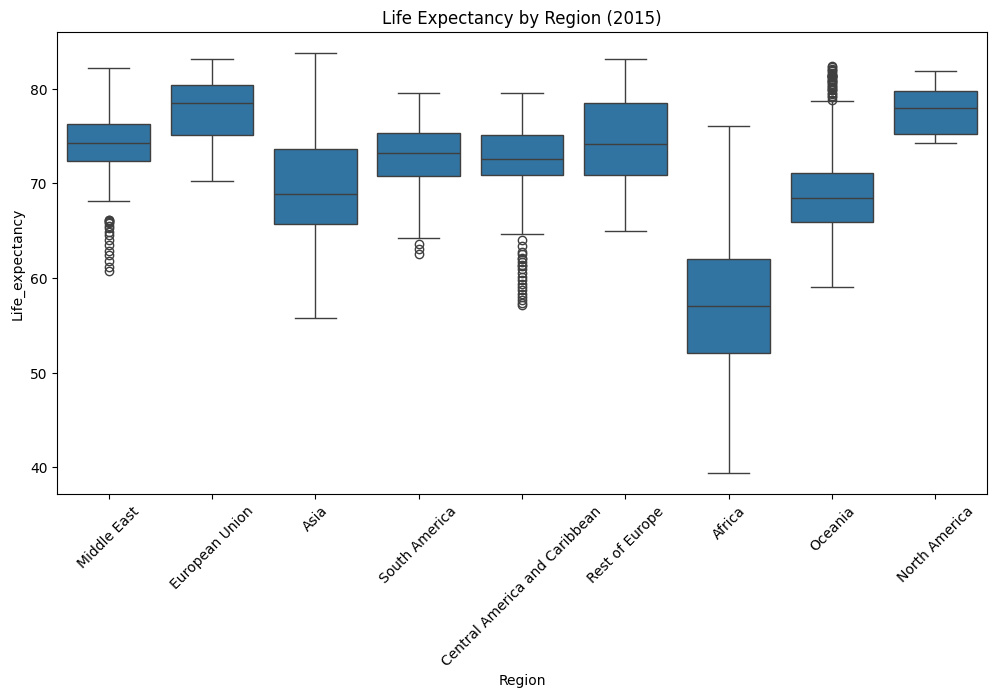

In [36]:
# Region별 Life_expectancy에 관한 boxplot -> 큰 의미는 없어보이지만 일단 한 번 해보았음
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Life_expectancy', data=df)
plt.title('Life Expectancy by Region (2015)')
plt.xticks(rotation=45)
plt.show()

### 4. 상관계수 히트맵
- 16개 연도를 다 하기는 힘들어서 2000년, 2015년만 하였습니다.
- 유의성 검정 역시 예시로써 변수 하나만 골라서 했습니다. 

#### 4-1. 전체 데이터 시각화

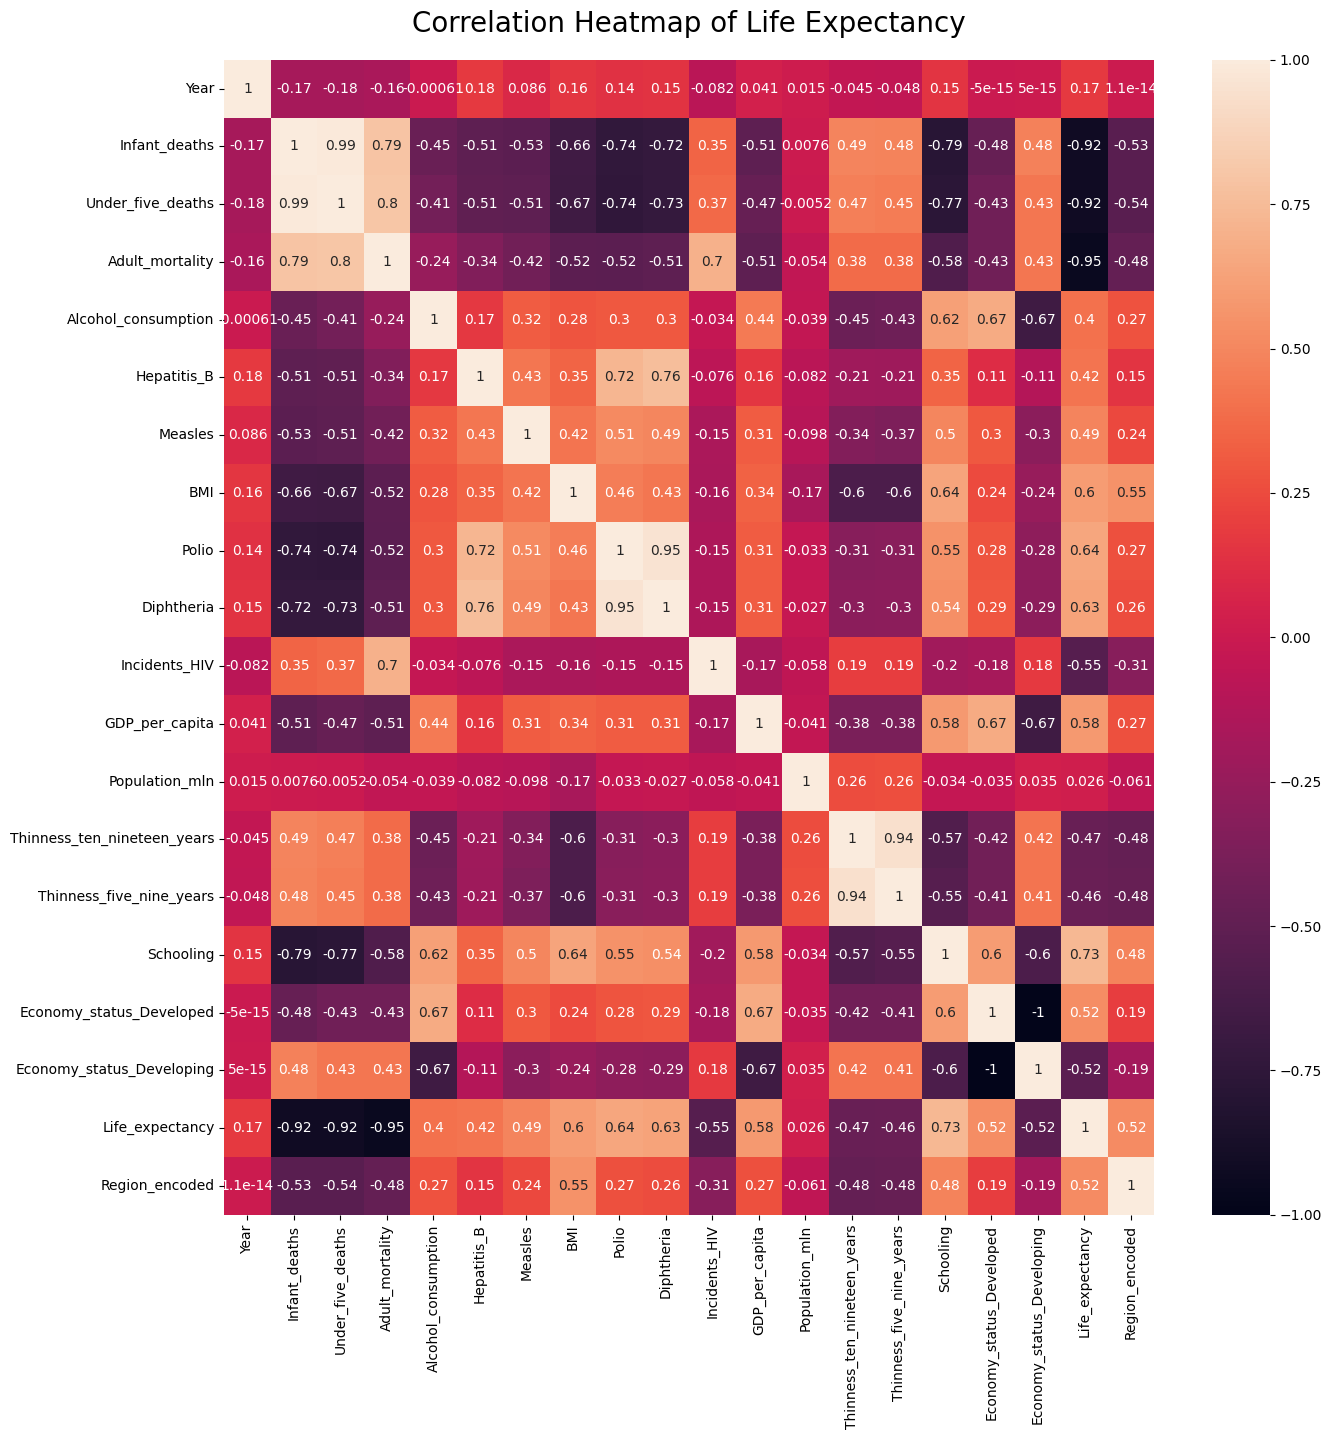

In [37]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Heatmap of Life Expectancy', fontsize=20, pad=20)
plt.show()

#### 간단한 가설 검정 용어 정리

- 귀무 가설($H_0$): 기존에 원래 알던 사실
- 대립 가설($H_1$): 새롭게 알게된 사실
- p-value: 귀무 가설(null hypothesis)이 맞다는 전제 하에, 표본에서 실제로 관측된 통계치와 같거나 유사한 통계치가 관측될 확률
    - p < 0.05: 귀무가설 기각 -> 통계적으로 유의하다
    - p > 0.05: 귀무가설 채택 -> 통계적으로 유의하지 않다

- 피어슨 상관계수의 유의성 검정

    - $H_0$: Measles와 Infant_deaths의 상관계수는 0이다. (두 변수 간에 선형 상관관계가 없다)
    - $H_1$: Measles와 Infant_deaths의 상관계수는 0이 아니다. (두 변수 간에 선형 상관관계가 있다.)

- 해석

    - $p$ < $0.05$: 귀무가설 기각 -> 두 변수 간 선형 상관관계가 있다. -> 통계적으로 유의하다.
    - $p$ >= $0.05$: 귀무가설 기각 -> 두 변수 간 선형 상관관계가 있다. -> 통계적으로 유의하지 않다.

In [38]:
from scipy import stats
stats.pearsonr(df['Polio'], df['Infant_deaths'])

# 상관관계는 -0.7407904606743126이므로 두 변수는 음의 상관관계를 갖는다. -> Measle의 백신 접종률이 올라가면 영아 사망률이 줄어든다.
# p-value가 7.98505878129076e-204이므로 0.05보다 작기 때문에 두 변수는 선형 상관관계가 있다.
# 즉, 해당 상관계수는 통계적으로 매우 유의하다.


PearsonRResult(statistic=np.float64(-0.7407904606743126), pvalue=np.float64(0.0))

##### 4-2. 2000년 데이터 시각화

In [39]:
df_2000 = df[df['Year']==2000]

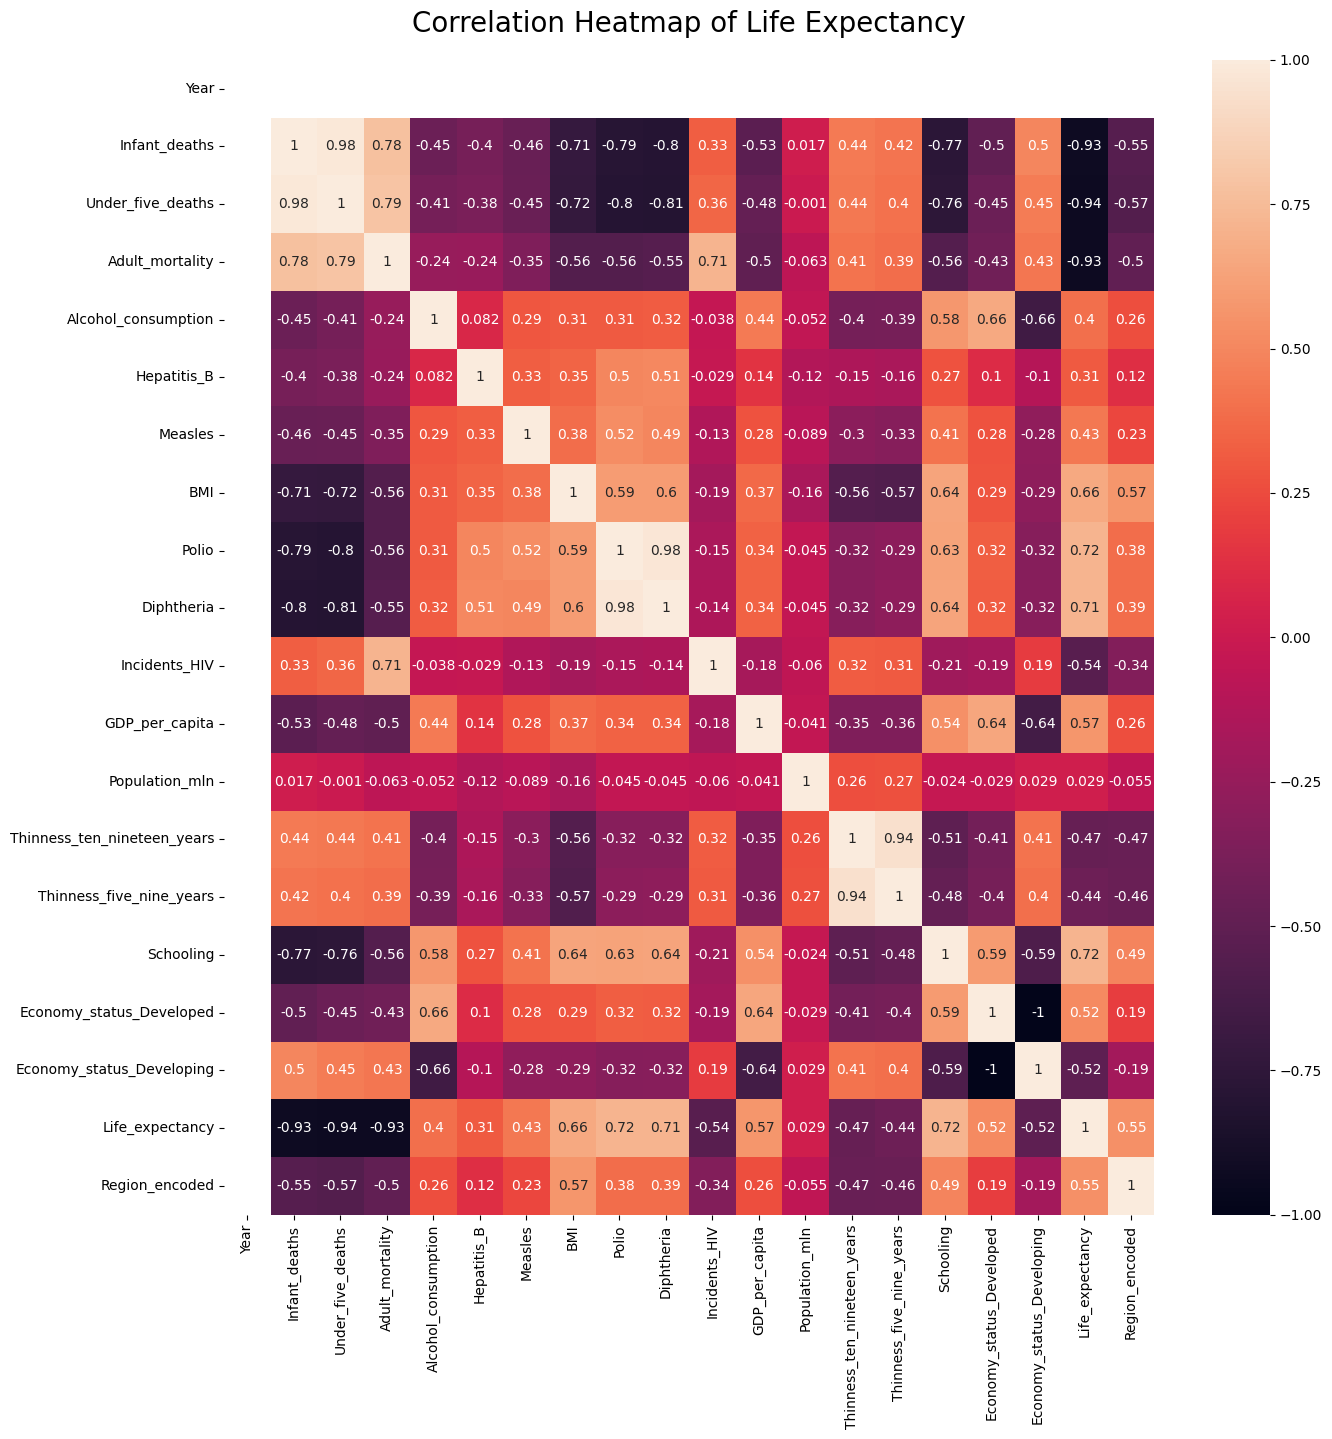

In [40]:
corr_matrix_2000 = df_2000.corr(numeric_only=True)
corr_matrix_2000 

plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix_2000, annot=True)
plt.title('Correlation Heatmap of Life Expectancy', fontsize=20, pad=20)
plt.show()

In [41]:

stats.pearsonr(df_2000['Measles'], df_2000['Infant_deaths'])

# 상관관계는 -0.46426121595949943이므로 두 변수는 음의 상관관계를 갖는다. -> Measle의 백신 접종률이 올라가면 영아 사망률이 줄어든다.
# p-value가 5.91211345284247e-11이므로 0.05보다 작기 때문에 두 변수는 선형 상관관계가 있다.
# 즉, 해당 상관계수는 통계적으로 매우 유의하다.

PearsonRResult(statistic=np.float64(-0.4642612159594995), pvalue=np.float64(5.91211345284247e-11))

##### 4-3. 2015년 데이터 시각화

In [42]:
df_2015 = df[df['Year']==2015]

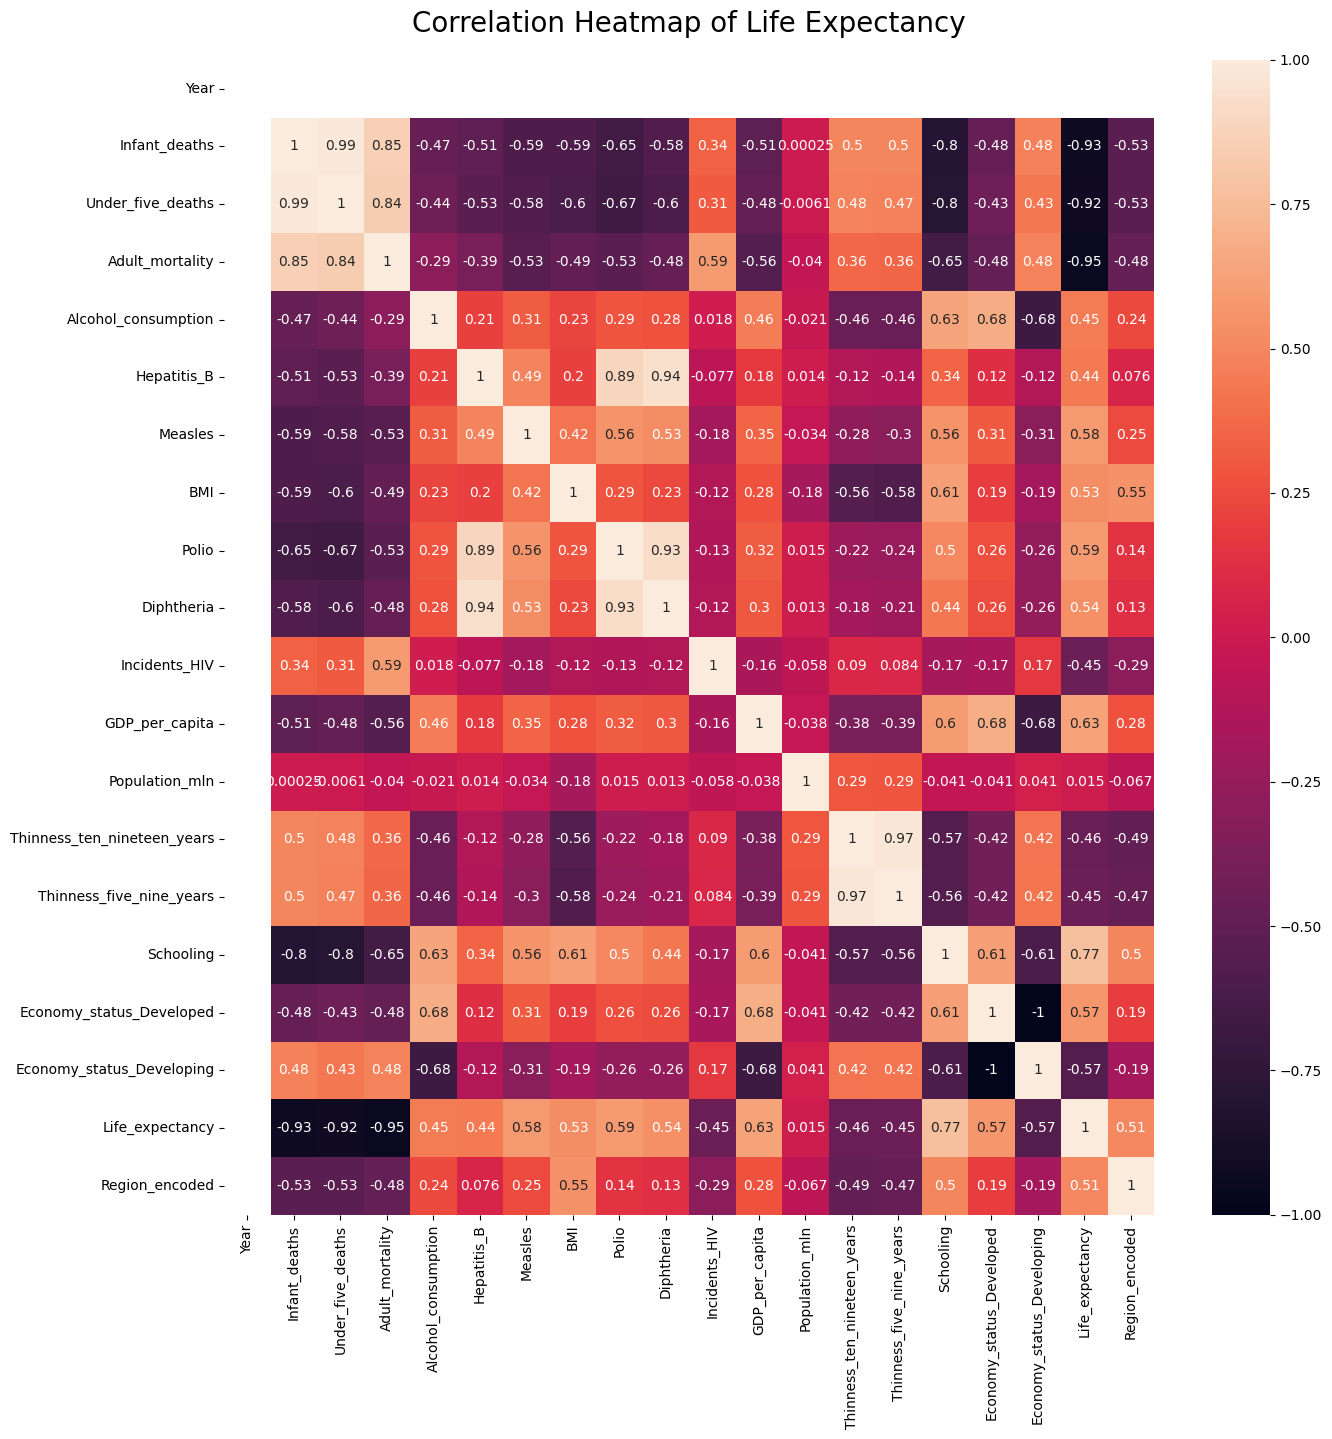

In [43]:
corr_matrix = df_2015.corr(numeric_only=True)
corr_matrix

plt.figure(figsize=(15, 15))
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Heatmap of Life Expectancy', fontsize=20, pad=20)
plt.show()

In [44]:
stats.pearsonr(df_2015['Measles'], df_2015['Infant_deaths'])


# 상관관계는 -0.5861101303876799이므로 두 변수는 음의 상관관계를 갖는다. -> Measle의 백신 접종률이 올라가면 영아 사망률이 줄어든다.
# p-value가 6.739777306337778e-18이므로 0.05보다 작기 때문에 두 변수는 선형 상관관계가 있다.
# 즉, 해당 상관계수는 통계적으로 매우 유의하다.

PearsonRResult(statistic=np.float64(-0.5861101303876799), pvalue=np.float64(6.739777306337778e-18))

### 5. 여러 가지 시각화 자료

#### 5-1. 연도, 지역별 GDP

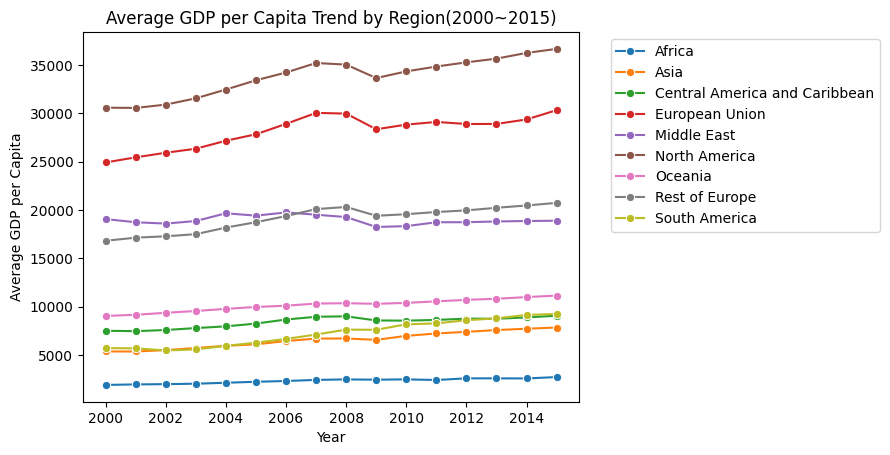

In [45]:
gdp_trend = df.groupby(['Year', 'Region'])['GDP_per_capita'].mean().reset_index()

plt.figure()
sns.lineplot(data=gdp_trend, x='Year', y='GDP_per_capita', hue='Region', marker='o')

plt.title('Average GDP per Capita Trend by Region(2000~2015)')
plt.ylabel('Average GDP per Capita')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

#### 5-2. 연도, 지역별 기대수명

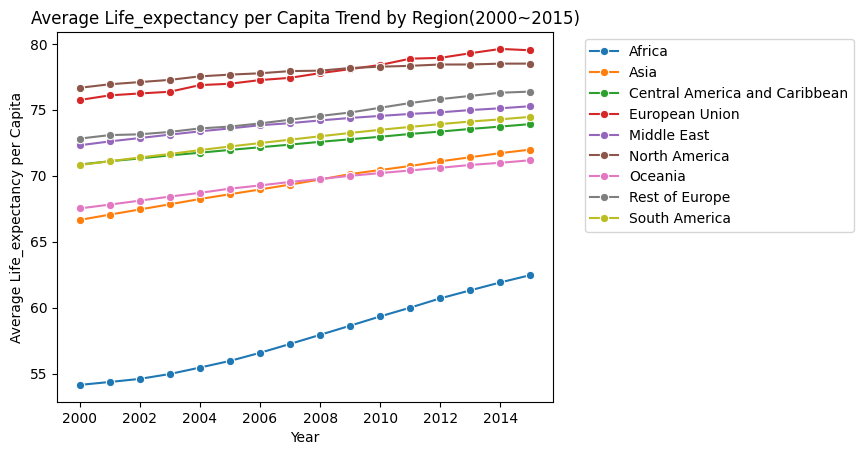

In [46]:
gdp_trend = df.groupby(['Year', 'Region'])['Life_expectancy'].mean().reset_index()

plt.figure()
sns.lineplot(data=gdp_trend, x='Year', y='Life_expectancy', hue='Region', marker='o')

plt.title('Average Life_expectancy per Capita Trend by Region(2000~2015)')
plt.ylabel('Average Life_expectancy per Capita')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

# 아프리카에서 기대수명의 가파른 증가가 보임 -> GDP에서는 급격한 증가폭이 보이지 않았기에 백신 접종률이 원인일지도 모르겠다는 생각을 함
# 백신 접종률만 따로 시각화

##### 5-3. 백신 접종률

- 아프리카

In [47]:
df_af = df[df['Region']=='Africa']

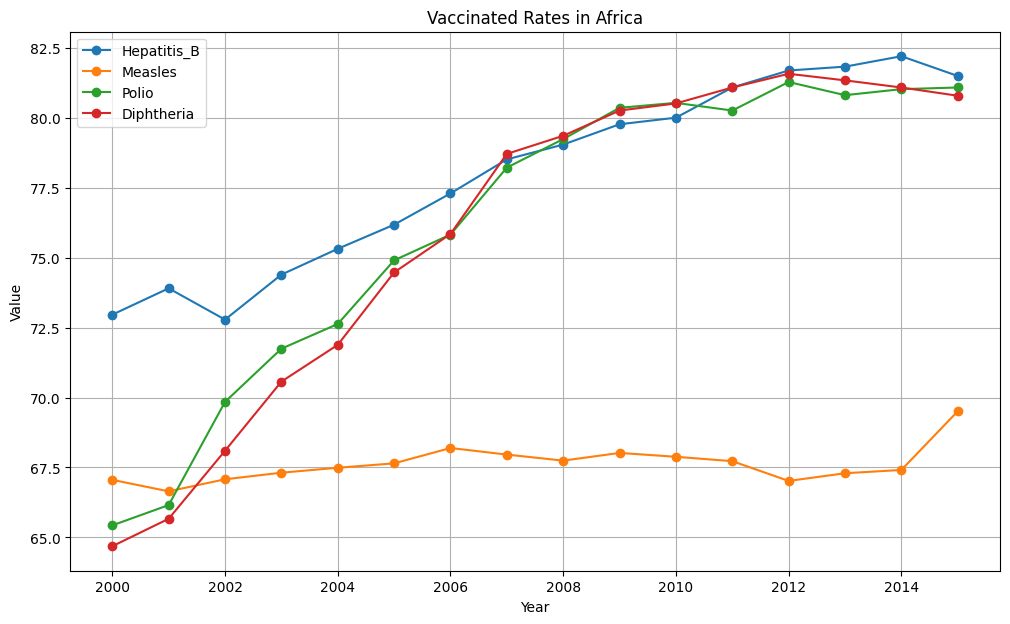

In [48]:
df_af = df_af.groupby('Year')[['Hepatitis_B', 'Measles', 'Polio', 'Diphtheria']].mean().reset_index()
df_af.set_index('Year').plot(figsize=(12, 7), marker='o')
plt.title('Vaccinated Rates in Africa')
plt.ylabel('Value')
plt.grid(True)
plt.show()

- 아프리카 데이터만을 가지고 백신 접종률과 기대수명을 비교한 결과임
    - 실제로 B형간염을 제외하면 대체로 상관계수(의 절댓값)이 큼

In [49]:
vaccine_cols = ['Hepatitis_B', 'Polio', 'Diphtheria', 'Life_expectancy']
corr = df[vaccine_cols].corr()
corr['Life_expectancy']

#실제로 Polio, Diphtheria는 아프리카 데이터에서 생존율과의 상관성이 높음

Hepatitis_B        0.417804
Polio              0.641217
Diphtheria         0.627541
Life_expectancy    1.000000
Name: Life_expectancy, dtype: float64

In [50]:
from scipy import stats
stats.pearsonr(df['Polio'], df['Life_expectancy']) #통계적으로 유의

PearsonRResult(statistic=np.float64(0.6412174553454272), pvalue=np.float64(0.0))

In [51]:
stats.pearsonr(df['Diphtheria'], df['Life_expectancy']) #통계적으로 유의

PearsonRResult(statistic=np.float64(0.6275413923742557), pvalue=np.float64(1.95292136713e-313))

- 아시아

In [52]:
df_as = df[df['Region']=='Asia']

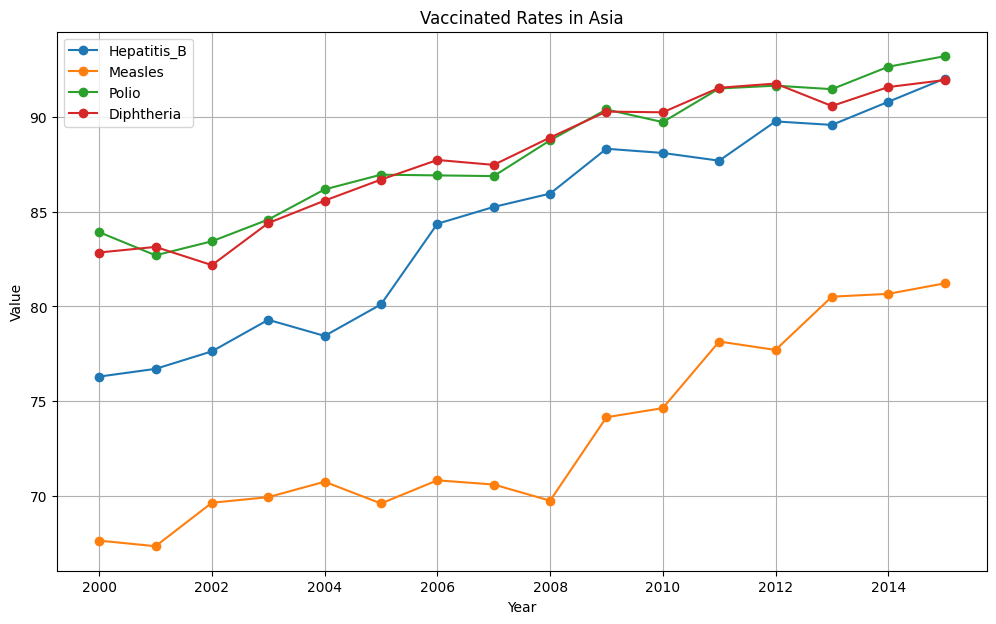

In [53]:
# 각각 백신 접종률
df_as = df_as.groupby('Year')[['Hepatitis_B', 'Measles', 'Polio', 'Diphtheria']].mean().reset_index()
df_as.set_index('Year').plot(figsize=(12, 7), marker='o')
plt.title('Vaccinated Rates in Asia')
plt.ylabel('Value')
plt.grid(True)
plt.show()

- 중앙아메리카, 카리브해

In [54]:
df_ca = df[df['Region']=='Central America and Caribbean']

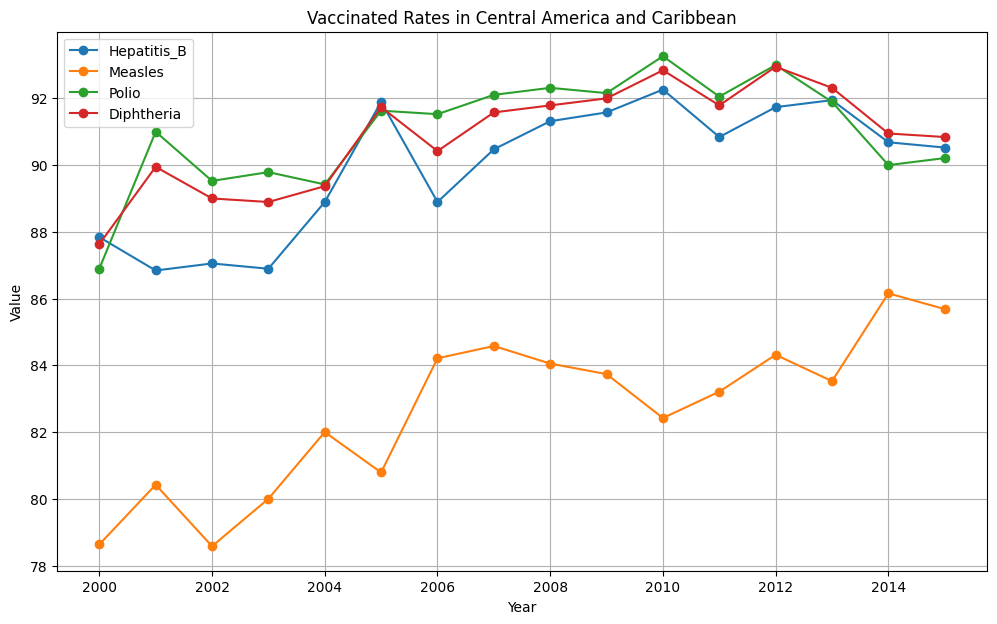

In [55]:
# 각각 백신 접종률
df_ca = df_ca.groupby('Year')[['Hepatitis_B', 'Measles', 'Polio', 'Diphtheria']].mean().reset_index()
df_ca.set_index('Year').plot(figsize=(12, 7), marker='o')
plt.title('Vaccinated Rates in Central America and Caribbean')
plt.ylabel('Value')
plt.grid(True)
plt.show()

- EU 국가들

In [56]:
df_eu = df[df['Region']=='European Union']

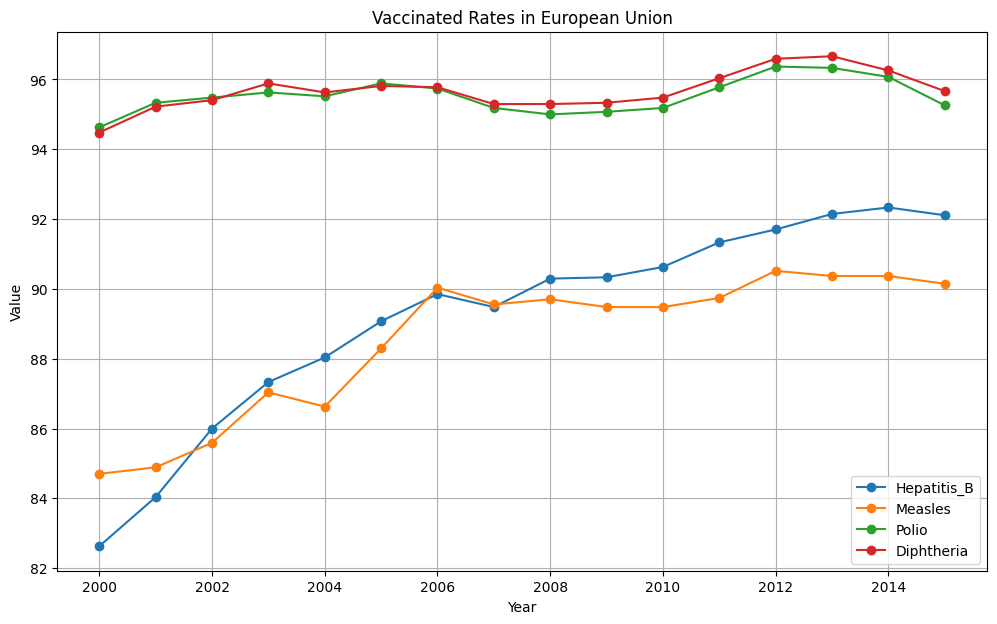

In [57]:
df_eu = df_eu.groupby('Year')[['Hepatitis_B', 'Measles', 'Polio', 'Diphtheria']].mean().reset_index()
df_eu.set_index('Year').plot(figsize=(12, 7), marker='o')
plt.title('Vaccinated Rates in European Union')
plt.ylabel('Value')
plt.grid(True)
plt.show()

- Middle East

In [58]:
df_me = df[df['Region']=='Middle East']

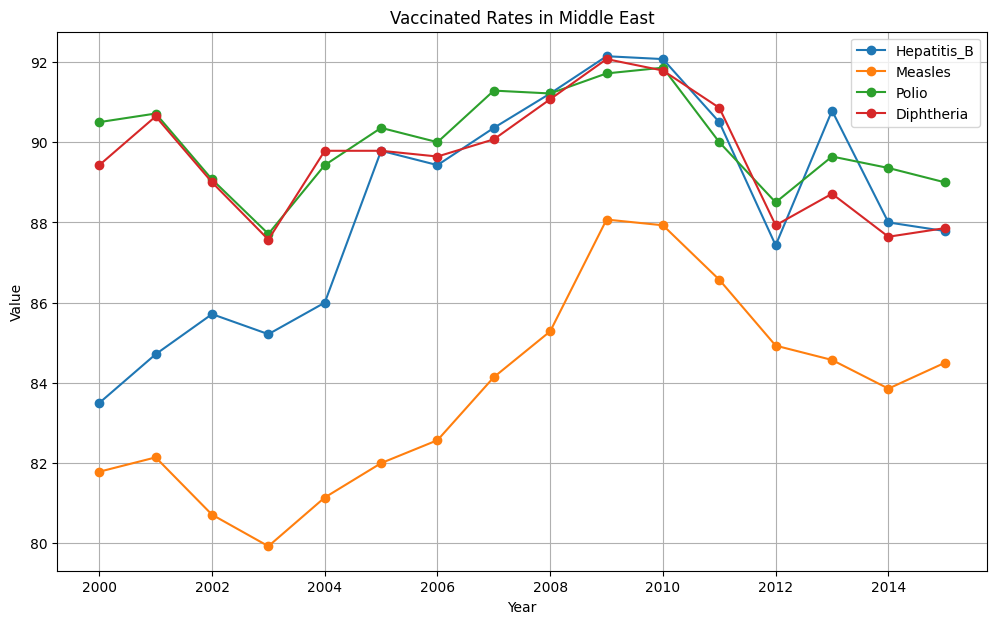

In [59]:
df_me = df_me.groupby('Year')[['Hepatitis_B', 'Measles', 'Polio', 'Diphtheria']].mean().reset_index()
df_me.set_index('Year').plot(figsize=(12, 7), marker='o')
plt.title('Vaccinated Rates in Middle East')
plt.ylabel('Value')
plt.grid(True)
plt.show()

- North America

In [60]:
df_na = df[df['Region']=='North America']

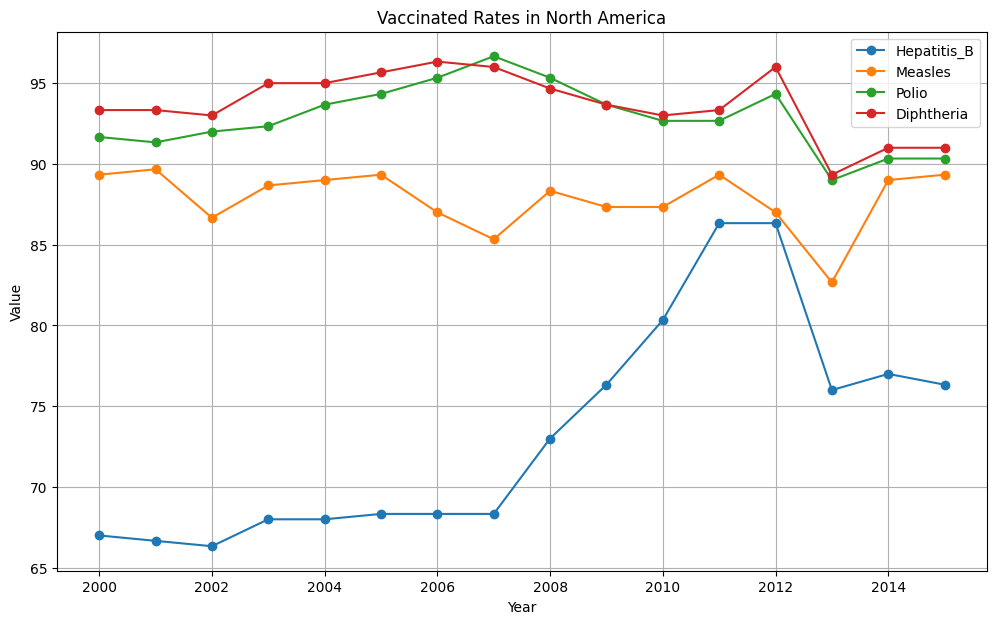

In [61]:
df_na = df_na.groupby('Year')[['Hepatitis_B', 'Measles', 'Polio', 'Diphtheria']].mean().reset_index()
df_na.set_index('Year').plot(figsize=(12, 7), marker='o')
plt.title('Vaccinated Rates in North America')
plt.ylabel('Value')
plt.grid(True)
plt.show()

- Oceania

In [62]:
df_oc = df[df['Region']=='Oceania']

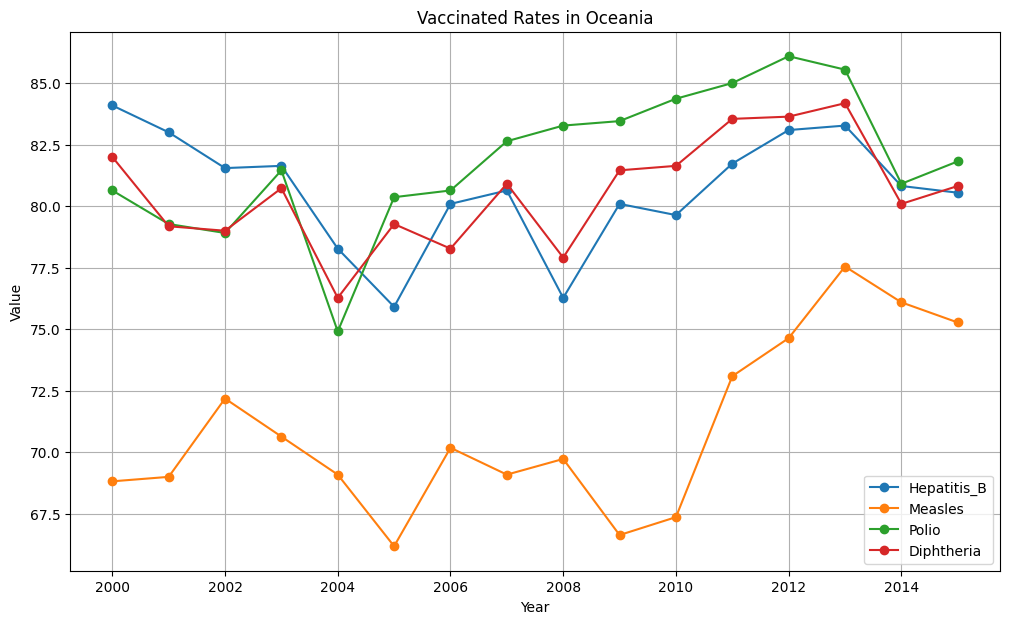

In [63]:
df_oc = df_oc.groupby('Year')[['Hepatitis_B', 'Measles', 'Polio', 'Diphtheria']].mean().reset_index()
df_oc.set_index('Year').plot(figsize=(12, 7), marker='o')
plt.title('Vaccinated Rates in Oceania')
plt.ylabel('Value')
plt.grid(True)
plt.show()

- Rest of Europe

In [64]:
df_re = df[df['Region']=='Rest of Europe']

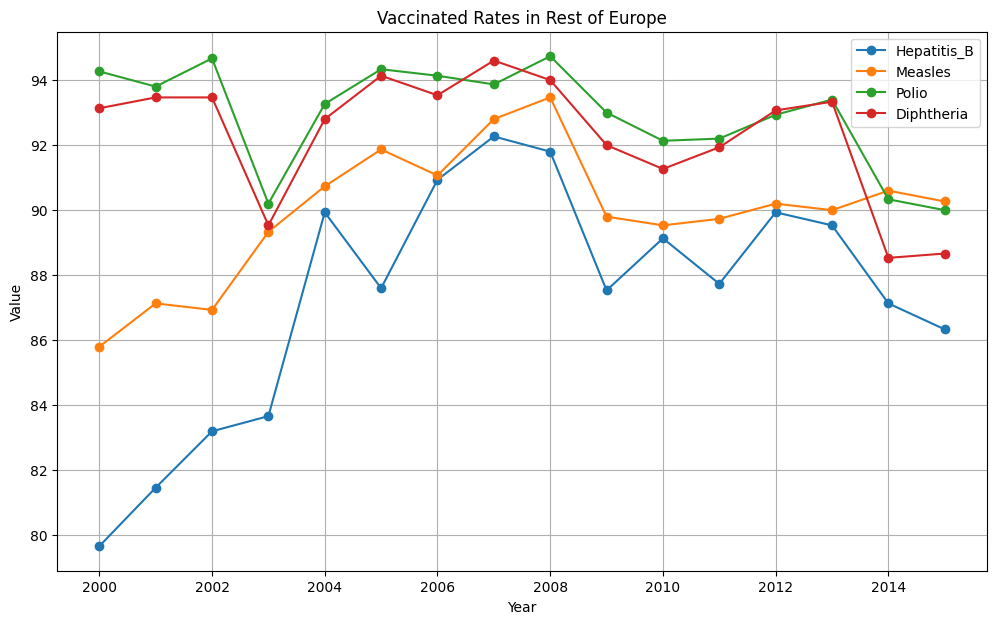

In [65]:
df_re = df_re.groupby('Year')[['Hepatitis_B', 'Measles', 'Polio', 'Diphtheria']].mean().reset_index()
df_re.set_index('Year').plot(figsize=(12, 7), marker='o')
plt.title('Vaccinated Rates in Rest of Europe')
plt.ylabel('Value')
plt.grid(True)
plt.show()

In [66]:
df_sa = df[df['Region']=='South America']

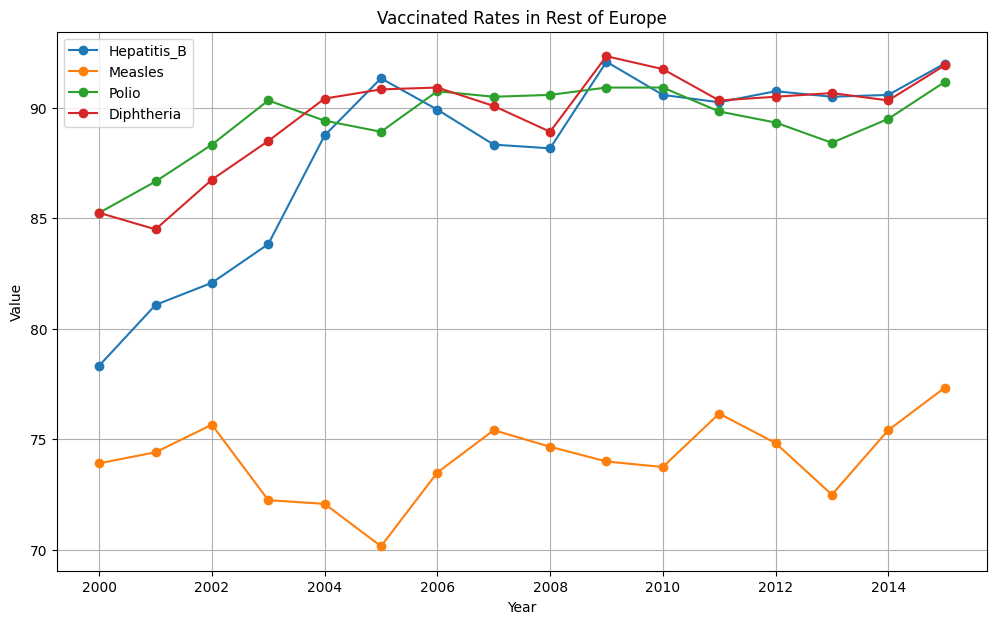

In [67]:
df_sa = df_sa.groupby('Year')[['Hepatitis_B', 'Measles', 'Polio', 'Diphtheria']].mean().reset_index()
df_sa.set_index('Year').plot(figsize=(12, 7), marker='o')
plt.title('Vaccinated Rates in Rest of Europe')
plt.ylabel('Value')
plt.grid(True)
plt.show()

#### 5-3. HIV 감염

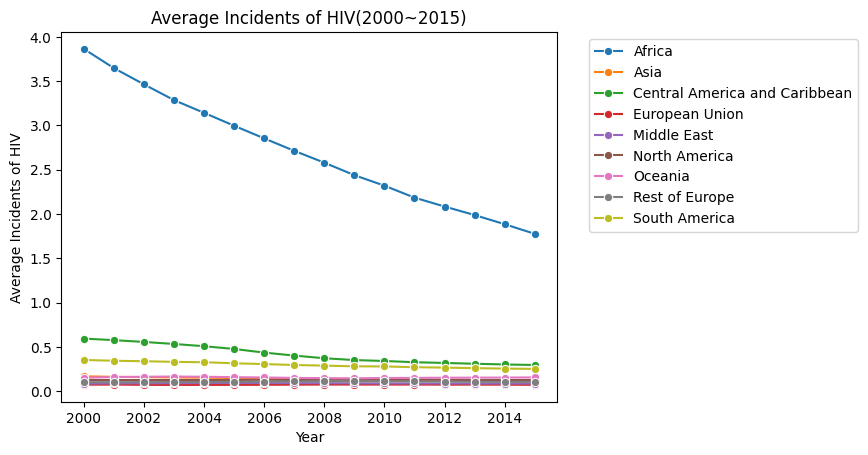

In [68]:
hiv_trend = df.groupby(['Year', 'Region'])['Incidents_HIV'].mean().reset_index()

plt.figure()
sns.lineplot(data=hiv_trend, x='Year', y='Incidents_HIV', hue='Region', marker='o')

plt.title('Average Incidents of HIV(2000~2015)')
plt.ylabel('Average Incidents of HIV')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

- 홍역 접종률을 제외한 나머지 접종률의 증가와 에이즈 감염률 감소가 아프리카의 평균 수명에 영향을 미쳤을 것이라 추정함
- 하지만 이걸 모든 대륙, 모든 상황에 다 적용할 수는 없음

#### 5-4. 교육연한

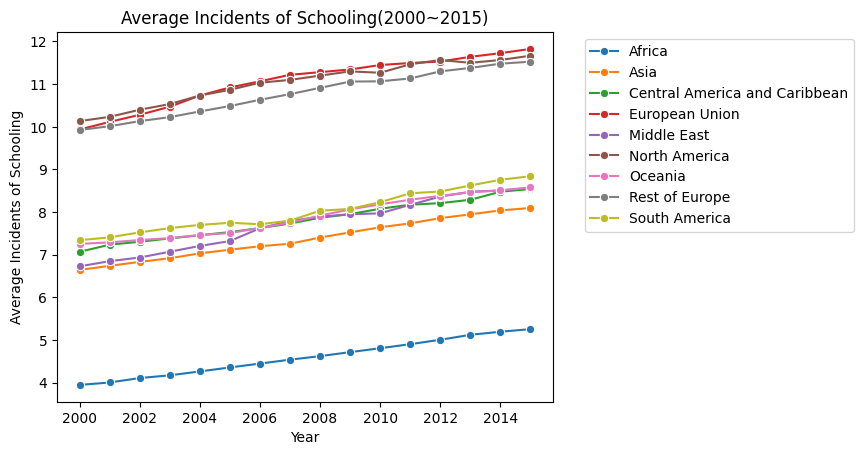

In [69]:
schooling_trend = df.groupby(['Year', 'Region'])['Schooling'].mean().reset_index()

plt.figure()
sns.lineplot(schooling_trend, x='Year', y='Schooling', hue='Region', marker='o')

plt.title('Average Incidents of Schooling(2000~2015)')
plt.ylabel('Average Incidents of Schooling')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

### 6. 회귀분석

- 수업시간에 배운 모델링 후 값을 예측하는 머신러닝 방법론과 정확히 동일하지만, sklearn의 LinearRegression은 예측만 가능하고, 회귀모형의 정확한 통계적 특질은 확인할 수 없기에 다른 라이브러리를 사용함
- 독립변수들이 종속변수들에 어느 정도로 영향을 미치고(회귀계수로 판단), 모델 그 자체와 독립변수들이 통계적으로 유의미한지를 확인 가능함
- $H_0$: 모든 독립변수의 회귀계수는 0이다. (독립변수들은 종속변수에 영향을 미치지 않는다.)
- $H_1$: 그 중에 하나라도 0이 아닌 게 있다. (독립변수는 종속변수에 영향을 미친다.)

---

- OLS Regression Results (봐야할 내용만 정리)
    - $R^2$: 높을 수록 좋음
    - $Prob$: 전체 회귀 모형의 유의성 <- p < 0.05이면 유의
    - coef: 회귀계수
    - P>|t|: 각각 독립변수들의 통계적 유의성 <- p < 0.05이면 유의

#### 6-1. 모든 독립변수를 다 포함해서 회귀분석을 돌림

In [71]:
import pandas as pd
import statsmodels.api as sm

# 1. 독립변수 정의
raw_features = [
    'Alcohol_consumption',
    'BMI',
    'Incidents_HIV',
    'GDP_per_capita',
    'Population_mln',
    'Thinness_ten_nineteen_years',
    'Thinness_five_nine_years',
    'Schooling',
    'Measles',
    'Polio',
    'Diphtheria',
    'Year',
    'Economy_status_Developed'
]

# 2. 독립변수 데이터프레임
x = df_2015[raw_features].copy()

# 3. Region 더미 변수 처리
region_dummies = pd.get_dummies(
    df_2015['Region_encoded'],
    prefix='Region',
    drop_first=True
)

x = pd.concat([x, region_dummies], axis=1)

# 4. 종속변수 + 상수항
y = df_2015['Life_expectancy']
x = sm.add_constant(x)

# 5. OLS 회귀
model = sm.OLS(y, x.astype(float)).fit()

# 6. 결과 출력
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        Life_expectancy   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     40.88
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           4.16e-52
Time:                        13:27:02   Log-Likelihood:                -458.99
No. Observations:                 179   AIC:                             960.0
Df Residuals:                     158   BIC:                             1027.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Alcohol_consumptio

#### 6-2. 통계적으로 유의미한 변수들로만 회귀분석 진행

In [72]:
import statsmodels.api as sm

# 1. 모든 독립변수를 한 번에 정의 (기존 변수 + 추가 변수)
# Year와 Economy_status_Developed는 수치/이진형이므로 그대로 포함
X_data = [
    'BMI', 'Incidents_HIV', 'GDP_per_capita', 'Schooling', 'Polio', 'Year'
]

# 2. 독립변수 데이터프레임 생성
x = df[X_data].copy()

# 4. 종속변수 설정 및 상수항 추가
y = df['Life_expectancy']
x = sm.add_constant(x)

# 5. 모델 적합 (모든 변수를 float 타입으로 변환하여 오류 방지)
model = sm.OLS(y, x).fit()

# 결과 출력
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_expectancy   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     2213.
Date:                Sun, 01 Feb 2026   Prob (F-statistic):               0.00
Time:                        13:27:07   Log-Likelihood:                -8003.2
No. Observations:                2864   AIC:                         1.602e+04
Df Residuals:                    2857   BIC:                         1.606e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -82.9872     32.771     -2.

In [73]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. VIF 계산을 위한 데이터 정리 (결측치 제거 및 타입 변환)
# OLS에 넣었던 x와 동일한 데이터를 사용합니다.
X_vif = x.astype(float)

# 2. VIF 계산
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# 3. 결과 출력 (VIF가 높은 순서대로 정렬)
print("\n### 다중공선성 결과 (VIF) ###")
print(vif_data.sort_values(by="VIF", ascending=False))


### 다중공선성 결과 (VIF) ###
          Feature            VIF
0           const  195957.592341
4       Schooling       2.555713
1             BMI       1.740335
3  GDP_per_capita       1.524814
5           Polio       1.486580
2   Incidents_HIV       1.053508
6            Year       1.039734


##### 최종회귀식
$y=-82.9872+0.6758BMI-1.5499IncidentsHIV+0.0001GDPpercapita+0.7658Schooling+0.1843Polio+0.0563Year$

#### 총평
1. 데이터를 핸들링하다 보니 아프리카의 기대수명이 다른 국가보다 가파르게 증가한 것을 발견
2. 원인이 무엇인지를 탐색하다 보니, 아프리카의 경우 GDP의 증가와 교육연한의 증가는 그렇게 가파르지 않음을 확인 -> GDP와 교육연한을 제외한 다른 요인이 있을 것이라 판단
3. 그렇다면, 백신 접종률(Polio, Diphtheria, Measles, Hepatitis_B) 혹은 HIV 감염(Incidents_HIV)의 감소가 유의미할 수 있겠다고 판단
4. 그래서 대륙별 백신 접종률의 평균과 HIV 감염의 감소에 대해 확인
5. 백신접종의 경우 아프리카 뿐 아니라 아시아 등 다른 국가에서도 가파른 증가가 관찰되기는 하나, 아프리카의 백신 접종률이 급격하게 증가하기는 했음
6. HIV 감염의 경우에서도 8개 대륙 중 아프리카가 눈에 띄게 감소함을 볼 수 있었음
7. 그렇지만 '백신 접종률과 HIV 감염이 기대수명에 영향을 미친다'라고 결론을 내리기에는 비약이 있기 때문에, 전체 국가를 대상으로 어떤 요인이 기대수명에 영향을 미치는지를 회귀분석을 통해 확인
    - 전체 데이터를 대상으로 회귀분석을 진행하였더니, 알코올 소비량, BMI, 인구, Thinness, Diphetheria, Measles, Hepatitis_B의 경우 통계적으로 유의하지 않기 때문에 제외함
    - 그 변수들을 전부 제외하고 회귀분석을 진행하였더니 모든 변수들이 다 유의하다는 결과가 나옴
    - 회귀 모형 역시, $R^2$=0.838, p-value<0.05이므로 통계적으로 유의함
    - 다중공선성 수치인 VIF도 매우 낮기 때문에 해당 회귀모형을 채택하는 데 크게 무리는 없음
8. 실제로 HIV 발병률이 감소할 수록 기대수명이 올라가고, Polio의 백신 접종률이 올라갈 수록 기대수명이 올라감
    - 나머지 백신들의 접종률 증가가 기대수명에 긍정적인 영향을 미친다는 것은 국소적으로만 적용할 수 있는 사례라고 볼 수 있겠음(혹은 영아사망률과 연관이 깊거나)

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")

# 데이터 로드
df = pd.read_csv("./data/Life-Expectancy-Data-Updated.csv")

# 컬럼명 공백 제거
df.columns = df.columns.str.strip()

df.head()


,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


#  대륙별 기대수명 추이 (EDA 핵심 그래프)

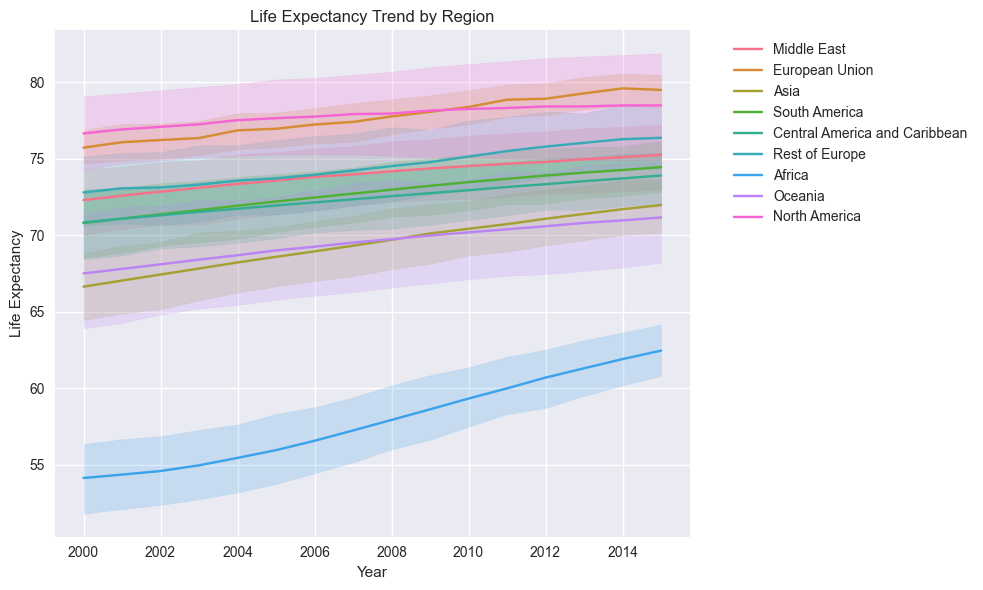

In [75]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df,
    x="Year",
    y="Life_expectancy",
    hue="Region",
    estimator="mean"
)
plt.title("Life Expectancy Trend by Region")
plt.ylabel("Life Expectancy")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


# 3️⃣ 아프리카 vs 기타 지역: GDP · Schooling 비교

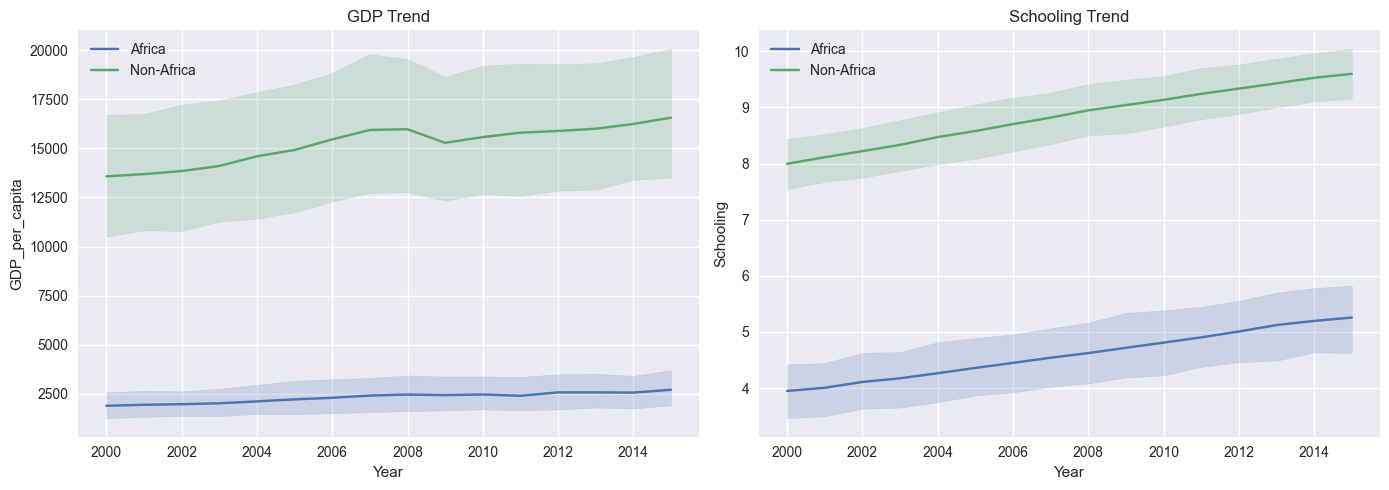

In [ ]:
africa = df[df["Region"] == "Africa"]
non_africa = df[df["Region"] != "Africa"]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.lineplot(data=africa, x="Year", y="GDP_per_capita", ax=axes[0], label="Africa")
sns.lineplot(data=non_africa, x="Year", y="GDP_per_capita", ax=axes[0], label="Non-Africa")
axes[0].set_title("GDP Trend")

sns.lineplot(data=africa, x="Year", y="Schooling", ax=axes[1], label="Africa")
sns.lineplot(data=non_africa, x="Year", y="Schooling", ax=axes[1], label="Non-Africa")
axes[1].set_title("Schooling Trend")

plt.tight_layout()
plt.show()


# 4️⃣ 백신 접종률 & HIV 추이 (아프리카 집중)

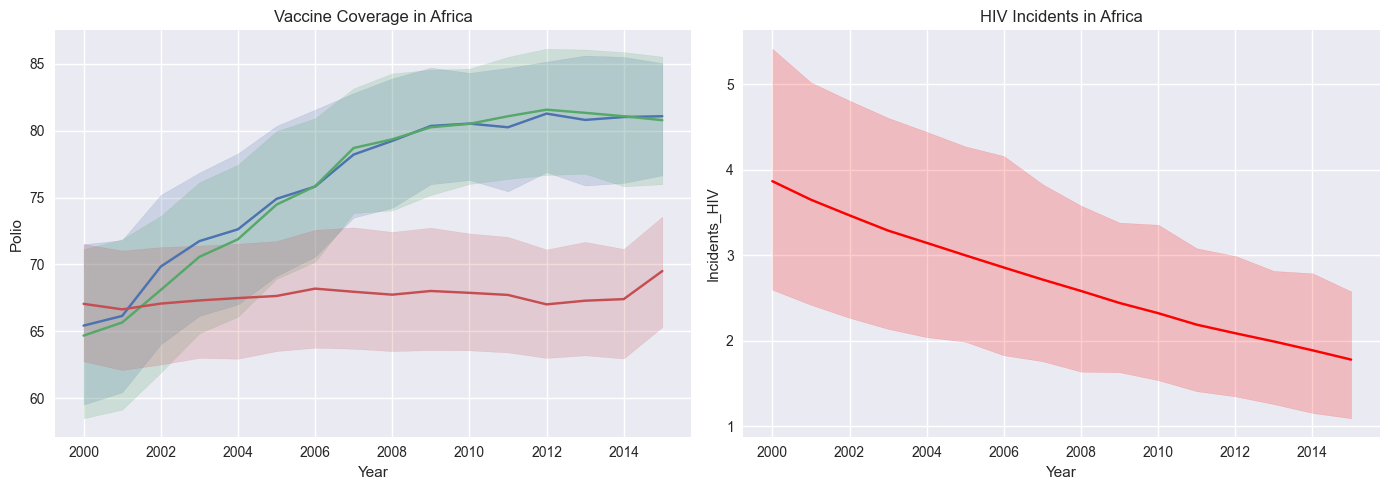

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.lineplot(data=africa, x="Year", y="Polio", ax=axes[0])
sns.lineplot(data=africa, x="Year", y="Diphtheria", ax=axes[0])
sns.lineplot(data=africa, x="Year", y="Measles", ax=axes[0])
axes[0].set_title("Vaccine Coverage in Africa")

sns.lineplot(data=africa, x="Year", y="Incidents_HIV", ax=axes[1], color="red")
axes[1].set_title("HIV Incidents in Africa")

plt.tight_layout()
plt.show()

# 5️⃣ 상관관계 확인 (백신 & HIV)

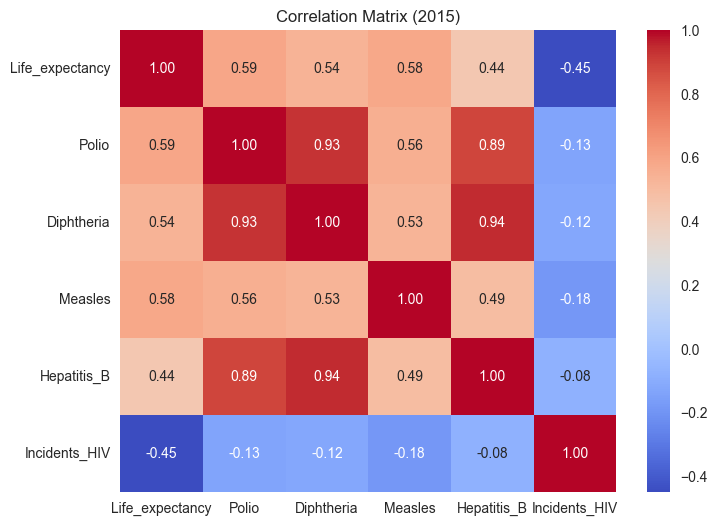

In [78]:
df_2015 = df[df["Year"] == 2015]

corr_vars = [
    "Life_expectancy",
    "Polio",
    "Diphtheria",
    "Measles",
    "Hepatitis_B",
    "Incidents_HIV"
]

corr = df_2015[corr_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (2015)")
plt.show()

# 6️⃣ OLS 회귀분석 (핵심 코드)

In [79]:
features = [
    "GDP_per_capita",
    "Schooling",
    "Incidents_HIV",
    "Polio",
    "Population_mln"
]

X = df_2015[features]
y = df_2015["Life_expectancy"]

# 결측치 제거
data = pd.concat([X, y], axis=1).dropna()
X = data[features]
y = data["Life_expectancy"]

# 상수항 추가
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Life_expectancy   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     120.2
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           2.25e-54
Time:                        13:35:00   Log-Likelihood:                -487.84
No. Observations:                 179   AIC:                             987.7
Df Residuals:                     173   BIC:                             1007.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             48.3110      2.000     24.

# 7️⃣ 다중공선성(VIF) 확인

In [80]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_df

,feature,VIF
0,const,50.739634
1,GDP_per_capita,1.568915
2,Schooling,1.890166
3,Incidents_HIV,1.043797
4,Polio,1.343364
5,Population_mln,1.008067


# 8️⃣ 핵심 해석용 시각화 (발표용)

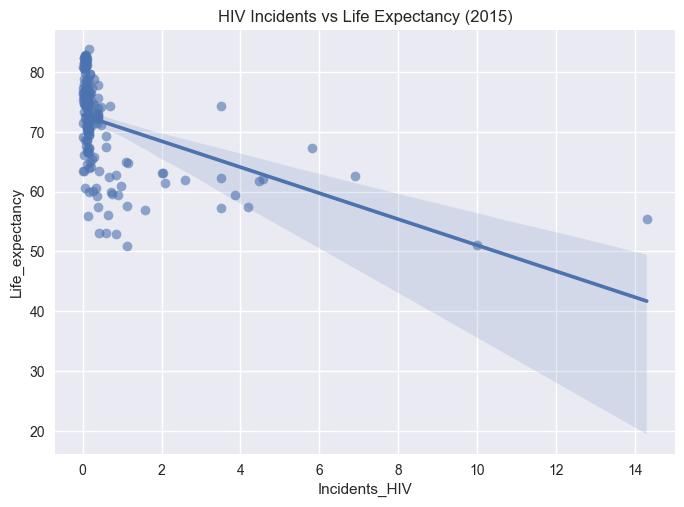

In [81]:
sns.regplot(
    data=df_2015,
    x="Incidents_HIV",
    y="Life_expectancy",
    scatter_kws={"alpha":0.6}
)
plt.title("HIV Incidents vs Life Expectancy (2015)")
plt.show()


# Polio vs 기대수명

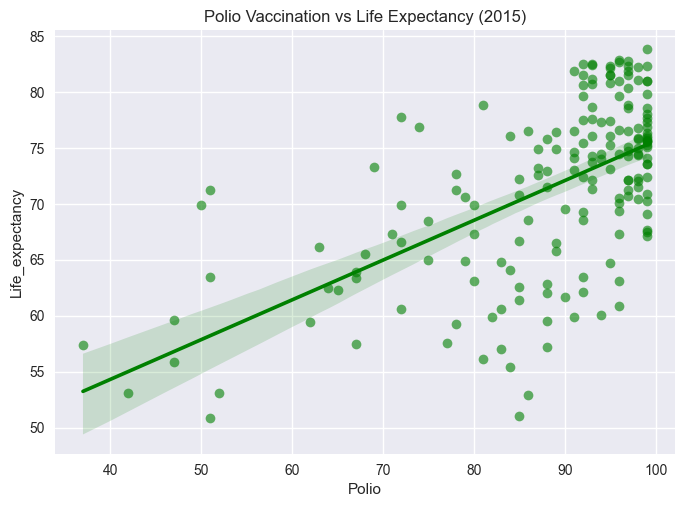

In [82]:
sns.regplot(
    data=df_2015,
    x="Polio",
    y="Life_expectancy",
    scatter_kws={"alpha":0.6},
    color="green"
)
plt.title("Polio Vaccination vs Life Expectancy (2015)")
plt.show()


# 3-1) 2015 기준 데이터 준비

In [83]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV

df_2015 = df[df["Year"] == 2015].copy()

target = "Life_expectancy"
vaccine_cols = ["Polio", "Diphtheria", "Measles", "Hepatitis_B"]
core_cols = ["Incidents_HIV", "GDP_per_capita", "Schooling", "Population_mln", "Economy_status_Developed"]

use_cols = [target] + vaccine_cols + core_cols
df_2015 = df_2015[use_cols].dropna()
df_2015.shape


(179, 10)

# 3-2) 백신끼리 “거의 같이 움직이는지” 상관 확인

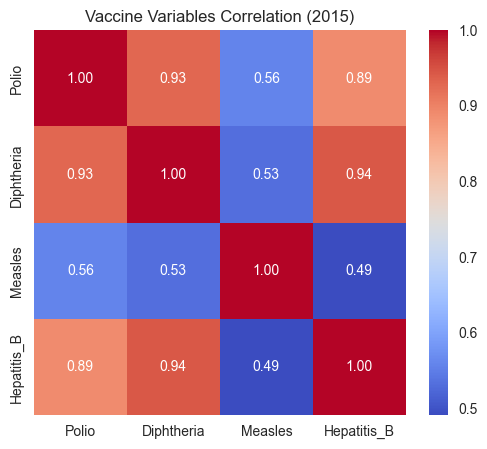

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_2015[vaccine_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Vaccine Variables Correlation (2015)")
plt.show()


# 3-3) Vaccine Index 만들기 (공선성 대응)

In [86]:
df_2015["Vaccine_Index"] = df_2015[vaccine_cols].mean(axis=1)


# 3-4) OLS 회귀 (Index 버전) + VIF

In [87]:
features = ["Vaccine_Index"] + core_cols
X = df_2015[features]
y = df_2015[target]

X_const = sm.add_constant(X)
ols = sm.OLS(y, X_const).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:        Life_expectancy   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     100.9
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           1.10e-53
Time:                        13:42:31   Log-Likelihood:                -486.94
No. Observations:                 179   AIC:                             987.9
Df Residuals:                     172   BIC:                             1010.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [88]:
vif_df = pd.DataFrame({
    "feature": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
})
vif_df


,feature,VIF
0,const,50.079345
1,Vaccine_Index,1.393897
2,Incidents_HIV,1.049396
3,GDP_per_capita,2.098249
4,Schooling,2.173981
5,Population_mln,1.007288
6,Economy_status_Developed,2.142012


# 3-5) LassoCV로 “변수 선택” 안정성 확인 (스케일링 포함)

In [89]:
X = df_2015[features]
y = df_2015[target]

pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42))
])

pipe.fit(X, y)

coef = pd.Series(pipe.named_steps["lasso"].coef_, index=features).sort_values(key=np.abs, ascending=False)
coef


Schooling                   3.331209
Incidents_HIV              -2.242856
Vaccine_Index               1.990410
GDP_per_capita              1.629084
Economy_status_Developed    0.307604
Population_mln              0.121351
dtype: float64

# 3-6) 부트스트랩: 유의성 흔들림(민감도) 시각화

In [91]:
import numpy as np

def bootstrap_coef(df_in, features, target, n_boot=300, seed=42):
    rng = np.random.default_rng(seed)
    coefs = []

    for _ in range(n_boot):
        samp = df_in.sample(len(df_in), replace=True, random_state=int(rng.integers(0, 1e9)))
        X = sm.add_constant(samp[features])
        y = samp[target]
        res = sm.OLS(y, X).fit()
        coefs.append(res.params)

    return pd.DataFrame(coefs)

boot = bootstrap_coef(df_2015, features, target, n_boot=300)
boot.describe(percentiles=[0.025, 0.5, 0.975])


,const,Vaccine_Index,Incidents_HIV,GDP_per_capita,Schooling,Population_mln,Economy_status_Developed
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,48.356209,0.159520,-1.506151,0.000098,1.059522,0.001591,0.719296
std,2.620133,0.034563,0.259126,0.000020,0.145231,0.003212,0.903407
min,39.705511,0.080689,-2.373647,0.000051,0.616891,-0.011891,-1.723009
2.5%,43.406937,0.099854,-2.117504,0.000065,0.769323,-0.003889,-1.091516
50%,48.437325,0.155991,-1.456866,0.000096,1.067778,0.001388,0.760586
97.5%,52.632507,0.225338,-1.152852,0.000141,1.335495,0.009741,2.398154
max,55.223496,0.288239,-1.020848,0.000168,1.457942,0.029918,3.140275


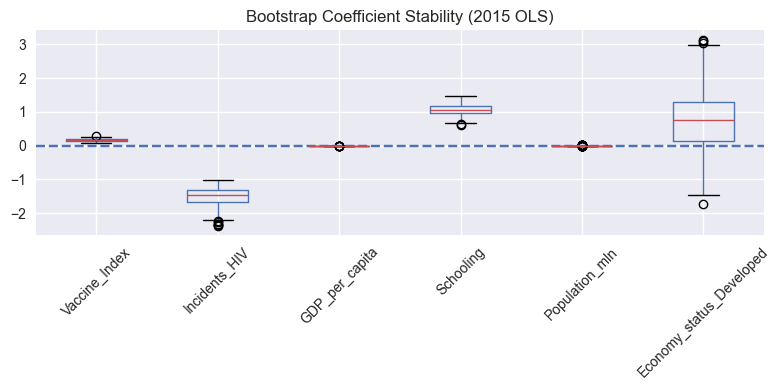

In [92]:
# 95% 구간이 0을 지나지 않는지(=방향 일관성) 시각적으로 확인
plt.figure(figsize=(8,4))
boot[features].boxplot(rot=45)
plt.axhline(0, linestyle="--")
plt.title("Bootstrap Coefficient Stability (2015 OLS)")
plt.tight_layout()
plt.show()


In [93]:
df.columns.tolist()


['Country',
 'Region',
 'Year',
 'Infant_deaths',
 'Under_five_deaths',
 'Adult_mortality',
 'Alcohol_consumption',
 'Hepatitis_B',
 'Measles',
 'BMI',
 'Polio',
 'Diphtheria',
 'Incidents_HIV',
 'GDP_per_capita',
 'Population_mln',
 'Thinness_ten_nineteen_years',
 'Thinness_five_nine_years',
 'Schooling',
 'Economy_status_Developed',
 'Economy_status_Developing',
 'Life_expectancy']

# ✅ 그래프 1 (핵심 요약용 · 강력 추천)
HIV 감소 & 백신 커버리지 vs 기대수명 (2015)

👉 “경제 말고 보건 요인이 눈에 띈다”를 한 컷에

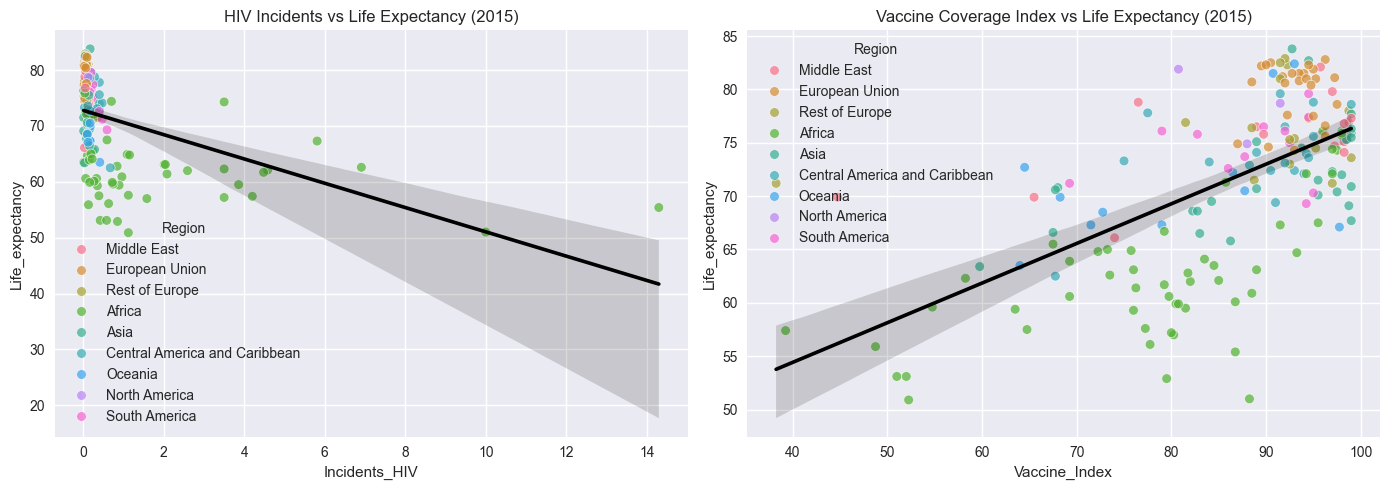

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2015 데이터
df_2015 = df[df["Year"] == 2015].copy()

# 백신 평균 인덱스
vaccine_cols = ["Polio", "Diphtheria", "Measles", "Hepatitis_B"]
df_2015["Vaccine_Index"] = df_2015[vaccine_cols].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# HIV vs Life Expectancy
sns.scatterplot(
    data=df_2015,
    x="Incidents_HIV",
    y="Life_expectancy",
    hue="Region",
    alpha=0.7,
    ax=axes[0]
)
sns.regplot(
    data=df_2015,
    x="Incidents_HIV",
    y="Life_expectancy",
    scatter=False,
    color="black",
    ax=axes[0]
)
axes[0].set_title("HIV Incidents vs Life Expectancy (2015)")

# Vaccine Index vs Life Expectancy
sns.scatterplot(
    data=df_2015,
    x="Vaccine_Index",
    y="Life_expectancy",
    hue="Region",
    alpha=0.7,
    ax=axes[1]
)
sns.regplot(
    data=df_2015,
    x="Vaccine_Index",
    y="Life_expectancy",
    scatter=False,
    color="black",
    ax=axes[1]
)
axes[1].set_title("Vaccine Coverage Index vs Life Expectancy (2015)")

plt.tight_layout()
plt.show()

# 발표 멘트 (그대로 읽어도 됨)

“GDP나 교육을 넣지 않아도, HIV 감소와 백신 커버리지는 기대수명과 명확한 방향성을 보입니다.”

# ✅ 그래프 2 (논쟁 방어용)
왜 Polio만 튀어 보였는지 설명하는 그래프

👉 “백신들이 다 같이 움직인다 → 대표 변수 하나만 살아남는다”

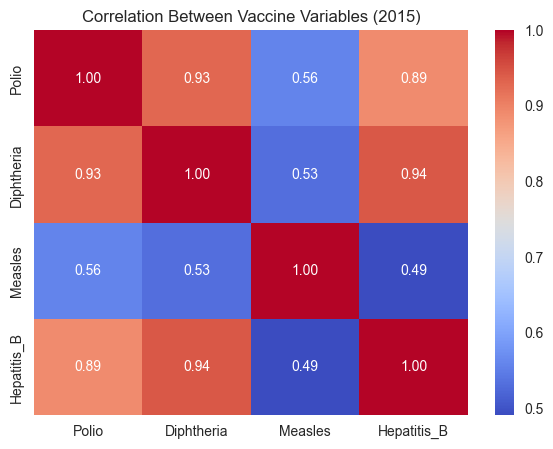

In [95]:
plt.figure(figsize=(7,5))
sns.heatmap(
    df_2015[vaccine_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Between Vaccine Variables (2015)")
plt.show()


# 멘트

“백신 변수들이 거의 같은 패턴으로 움직여서, 회귀에서는 하나의 대표 변수만 유의하게 남을 수 있습니다.”

→ Polio만 유의했던 이유를 직관적으로 납득시킴

# 그래프 3 (아프리카 스토리 한 컷)
아프리카: 경제 vs 보건 요인 비교

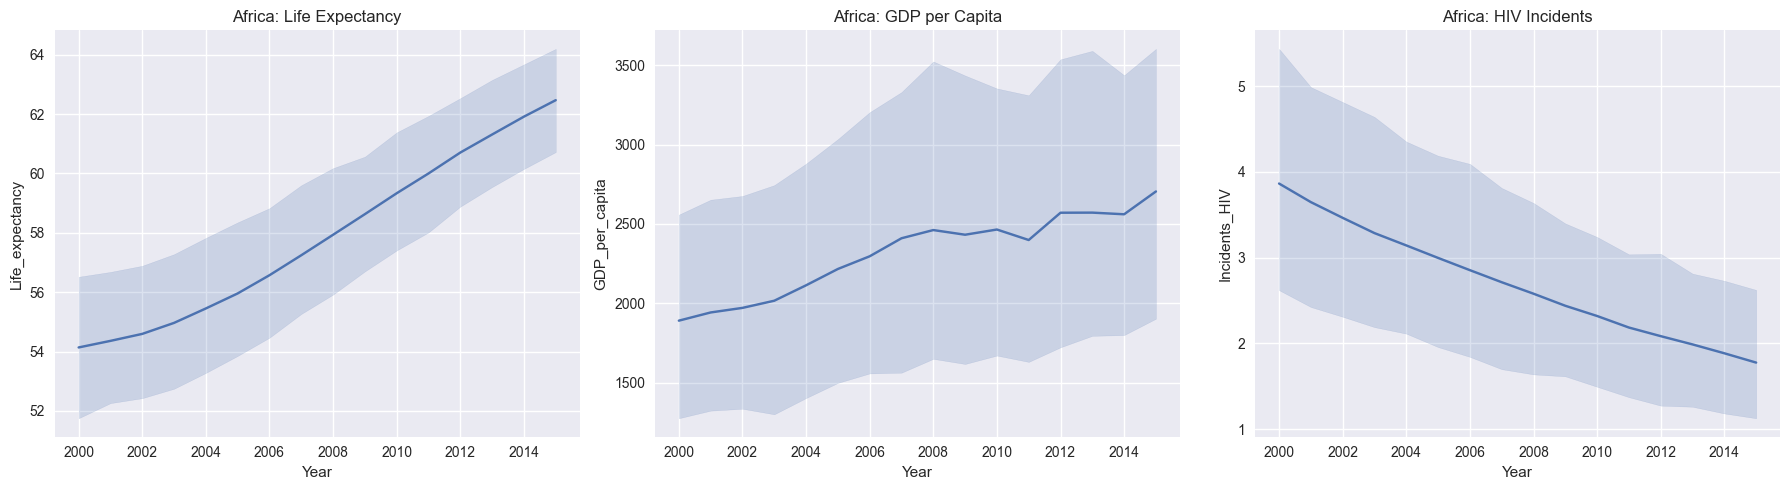

In [96]:
africa = df[df["Region"] == "Africa"]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.lineplot(data=africa, x="Year", y="Life_expectancy", ax=axes[0])
axes[0].set_title("Africa: Life Expectancy")

sns.lineplot(data=africa, x="Year", y="GDP_per_capita", ax=axes[1])
axes[1].set_title("Africa: GDP per Capita")

sns.lineplot(data=africa, x="Year", y="Incidents_HIV", ax=axes[2])
axes[2].set_title("Africa: HIV Incidents")

plt.tight_layout()
plt.show()


# 🎤 멘트

“GDP는 완만하지만, HIV 감소와 함께 기대수명은 빠르게 상승합니다.”

# C번 주제 정의
연구 질문

기대수명이 비슷한 국가들은 정말 비슷한 구조를 가지고 있을까?

👉 결론을 “원인”이 아니라 “구조 차이”로 가져가기 때문에 안전하고 설득력 있음

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

df = pd.read_csv("./data/Life-Expectancy-Data-Updated.csv")
df.columns = df.columns.str.strip()

df.head()


,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


# 1️⃣ 분석 기준 연도 선택

2015년: 가장 최신 + 데이터 안정적

In [98]:
df_2015 = df[df["Year"] == 2015].copy()
df_2015.shape


(179, 21)

# 2️⃣ 기대수명 구간(카테고리) 생성 ⭐ 핵심

“비슷한 기대수명”을 범주화해서 구조 비교

In [99]:
bins = [0, 55, 65, 75, 85]
labels = ["Low", "Mid-Low", "Mid-High", "High"]

df_2015["LifeGroup"] = pd.cut(
    df_2015["Life_expectancy"],
    bins=bins,
    labels=labels
)

df_2015["LifeGroup"].value_counts()


LifeGroup
High        69
Mid-High    68
Mid-Low     37
Low          5
Name: count, dtype: int64

# 3️⃣ 비교할 구조 변수 선택

“경제 / 교육 / 보건”을 대표하는 최소 변수 세트

In [100]:
structure_cols = [
    "GDP_per_capita",
    "Schooling",
    "Incidents_HIV",
    "Polio",
    "Infant_deaths"
]


# 4️⃣ 기대수명 그룹별 평균 구조 계산

In [101]:
group_profile = (
    df_2015
    .groupby("LifeGroup")[structure_cols]
    .mean()
)

group_profile


C:\Users\Playdata\AppData\Local\Temp\ipykernel_2172\181118727.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("LifeGroup")[structure_cols]


,GDP_per_capita,Schooling,Incidents_HIV,Polio,Infant_deaths
LifeGroup,,,,,
Low,1114.800000,4.400000,2.594000,63.200000,82.120000
Mid-Low,2118.918919,4.816216,1.817297,77.918919,50.932432
Mid-High,5607.073529,8.388235,0.326176,89.161765,21.420588
High,25989.000000,10.521739,0.097971,94.739130,6.743478
